In [ ]:
## Tratamiento de datos
import numpy as np
import pandas as pd
import json

## Preprocesado y modelado
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Gráficos
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# CARGA DEL JSON Y EXTRACCIÓN DE CATEGORÍAS
with open('MX_category_id.json', 'r') as f:
    categories_data = json.load(f)

In [ ]:
# Crear un diccionario mapeando 'id' al 'title' de la categoría
id_to_category = {}
for category in categories_data['items']:
    # El id en el JSON viene como string, lo convertimos a float para que coincida con el CSV
    cat_id = float(category['id'])
    cat_title = category['snippet']['title']
    id_to_category[cat_id] = cat_title

In [ ]:
# Convertir a DataFrame para facilitar la unión (merge)
df_categories = pd.DataFrame(list(id_to_category.items()), columns=['category_id', 'category_name'])

In [ ]:
df_videos = pd.read_csv('MXvideos_cc50_202101.csv', delimiter= ',')

In [ ]:
# UNIÓN DEL DATASET CON LAS CATEGORÍAS
# Unimos por la columna 'category_id'
df = pd.merge(df_videos, df_categories, on='category_id', how='left')

In [ ]:
print("--- PRIMEROS 5 REGISTROS ---")
df.head()

--- PRIMEROS 5 REGISTROS ---


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
0,SbOwzAl9ZfQ,17.14.11,Capítulo 12 | MasterChef 2017,MasterChef 2017,24.0,13/11/2017 1:06,"MasterChef Junior 2017|""TV Azteca""|""recetas""|""...",310130.0,4182.0,361.0,...,https://i.ytimg.com/vi/SbOwzAl9ZfQ/default.jpg,FALSO,FALSO,FALSO,Disfruta la presencia del Chef Torreblanca en ...,Tlaxcala,19.319995,-98.230010,POINT (-98.2300096 19.31999514),Entertainment
1,klOV6Xh-DnI,17.14.11,ALEXA EX-INTEGRANTE DEL GRUPO TIMBIRICHE RENUN...,Micky Contreras Martinez,22.0,13/11/2017 0:11,La Voz Mexico 7,104972.0,271.0,174.0,...,https://i.ytimg.com/vi/klOV6Xh-DnI/default.jpg,FALSO,FALSO,FALSO,ALEXA EX-INTEGRANTE DEL GRUPO TIMBIRICHE RENUN...,Michoacan,19.679973,-100.569996,POINT (-100.569996 19.67997316),People & Blogs
2,6L2ZF7Qzsbk,17.14.11,LOUIS CKAGÓ - EL PULSO DE LA REPÚBLICA,El Pulso De La República,25.0,13/11/2017 12:00,"Chumel Torres|""El Pulso de la Republica""|""noti...",136064.0,10105.0,266.0,...,https://i.ytimg.com/vi/6L2ZF7Qzsbk/default.jpg,FALSO,FALSO,FALSO,La canción del principio se llama “Este espíri...,Guerrero,17.549974,-99.500010,POINT (-99.5000096 17.54997398),News & Politics
3,hcY52MFWMDM,17.14.11,Sismo de 6.7 sacude Costa Rica 12 Noviembre 2017,Casanare,25.0,12/11/2017 22:47,"temblor|""costa rica""|""sismo en costa rica""",96153.0,378.0,171.0,...,https://i.ytimg.com/vi/hcY52MFWMDM/default.jpg,FALSO,FALSO,FALSO,El video es de un Walmart en el pais centroame...,Hidalgo,20.170434,-98.730031,POINT (-98.73003076000001 20.17043418),News & Politics
4,_OXDcGPVAa4,17.14.11,DOG HACKS | MUSAS LESSLIE LOS POLINESIOS,Musas,26.0,13/11/2017 14:17,"MUSAS|""lesslie""|""karen""|""hacks""|""perros""|""dogs...",499965.0,57781.0,681.0,...,https://i.ytimg.com/vi/_OXDcGPVAa4/default.jpg,FALSO,FALSO,FALSO,MI HERMANO NARRA MI RUTINA DE MAQUILLAJE\nhttp...,Jalisco,19.770019,-104.369997,POINT (-104.3699966 19.77001935),Howto & Style


In [ ]:
print("\n--- INFORMACIÓN DEL DATASET (Tamaño) ---")
df.shape


--- INFORMACIÓN DEL DATASET (Tamaño) ---


(44043, 21)

In [ ]:
print("\n--- INFORMACIÓN DEL DATASET (Tipos de datos y Nulos) ---")
df.info()


--- INFORMACIÓN DEL DATASET (Tipos de datos y Nulos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44043 entries, 0 to 44042
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                43959 non-null  object 
 1   trending_date           40593 non-null  object 
 2   title                   40510 non-null  object 
 3   channel_title           40501 non-null  object 
 4   category_id             40451 non-null  float64
 5   publish_time            40451 non-null  object 
 6   tags                    40480 non-null  object 
 7   views                   40451 non-null  float64
 8   likes                   40451 non-null  float64
 9   dislikes                40451 non-null  float64
 10  comment_count           40451 non-null  float64
 11  thumbnail_link          40471 non-null  object 
 12  comments_disabled       40451 non-null  object 
 13  ratings_disabled        40451 non

In [ ]:
print("\n--- ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas) ---")
df.describe()


--- ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas) ---


,category_id,views,likes,dislikes,comment_count,lat,lon
count,40451.000000,4.045100e+04,4.045100e+04,4.045100e+04,40451.000000,44043.000000,44043.000000
mean,21.003140,3.423820e+05,1.586184e+04,7.471604e+02,2039.660008,21.481515,-100.242120
std,5.878995,1.714691e+06,8.108987e+04,1.095358e+04,13938.031797,3.502304,6.018379
min,1.000000,1.570000e+02,0.000000e+00,0.000000e+00,0.000000,16.429991,-116.009260
25%,20.000000,1.681300e+04,2.990000e+02,1.700000e+01,42.000000,18.920381,-103.500024
50%,24.000000,5.697300e+04,1.246000e+03,6.300000e+01,196.000000,20.379982,-99.669999
75%,24.000000,2.068940e+05,7.226000e+03,2.670000e+02,885.000000,22.733353,-98.230010
max,43.000000,1.009124e+08,4.470923e+06,1.353667e+06,905925.000000,30.764051,-86.711455


In [ ]:
print("\n--- ESTADÍSTICAS DESCRIPTIVAS (Variables Categóricas) ---")
df.describe(include=['O'])


--- ESTADÍSTICAS DESCRIPTIVAS (Variables Categóricas) ---


,video_id,trending_date,title,channel_title,publish_time,tags,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,geometry,category_name
count,43959,40593,40510,40501,40451,40480,40471,40451,40451,40451,36246,44043,44043,40199
unique,34250,272,33821,7005,29061,23647,33949,2,2,2,26727,32,32,15
top,\n,18.26.05,"Bachatas 2018 Romanticas - Prince Royce, Shaki...",Cracks,22/03/2018 23:00,[none],Don Pollo,FALSO,FALSO,FALSO,SUSCRIBETE es FACIL http://goo.gl/aLNQ6X\nIMP...,Morelos,POINT (-99.23999963999999 18.92110476),Entertainment
freq,794,200,30,186,17,7685,17,40011,39817,40427,93,1441,1441,13487


In [ ]:
# TABLAS DE FRECUENCIA INICIALES
print("\n--- TABLA DE FRECUENCIA: Top 10 Categorías más frecuentes ---")
df['category_name'].value_counts().head(10)


--- TABLA DE FRECUENCIA: Top 10 Categorías más frecuentes ---


,count
category_name,
Entertainment,13487
People & Blogs,8159
Sports,4050
Music,3371
News & Politics,3113
Howto & Style,2467
Comedy,1742
Film & Animation,1298
Gaming,994


In [ ]:
# TABLAS DE FRECUENCIA INICIALES
print("\n--- TABLA DE FRECUENCIA: Top 10 Canales con más videos en tendencias ---")
df['channel_title'].value_counts().head(10)


--- TABLA DE FRECUENCIA: Top 10 Canales con más videos en tendencias ---


,count
channel_title,
Cracks,186
Badabun,184
Troom Troom Es,168
Cracks MX,162
Las Estrellas,155
Televisa Telenovelas,149
El Salvador 4K,145
Tu COSMOPOLIS,143
Enamorándonos,136


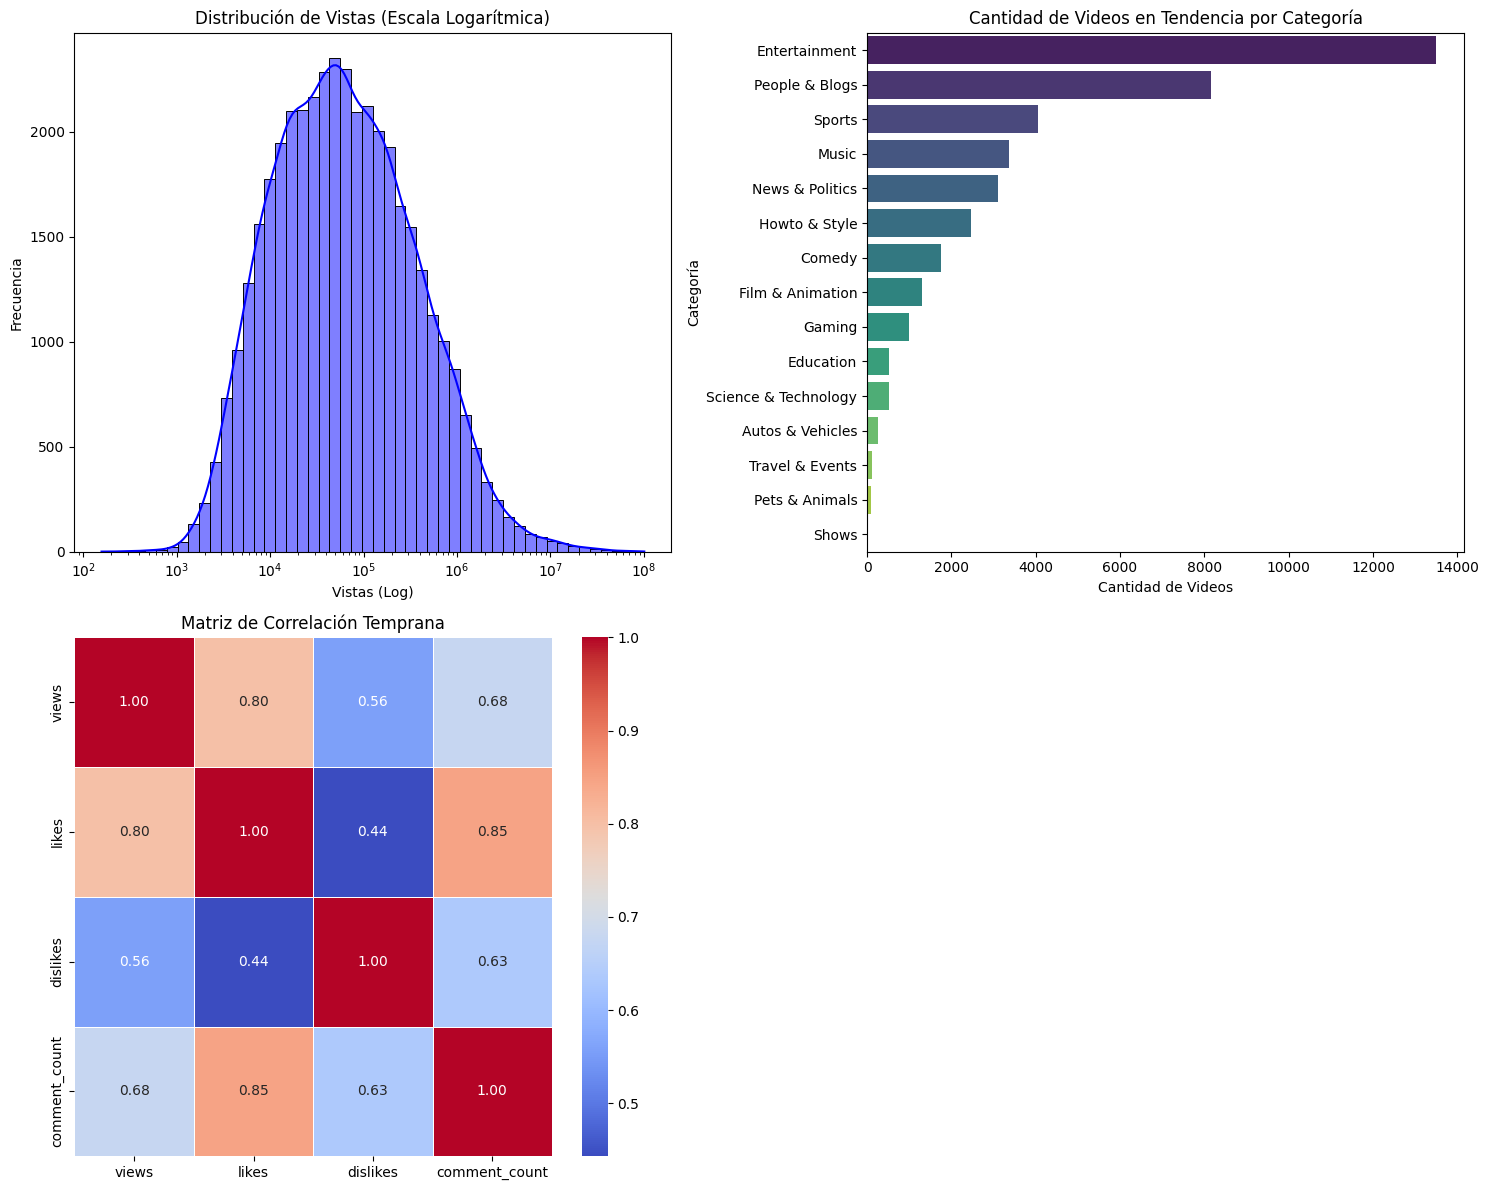

In [ ]:
# VISUALIZACIÓN INICIAL DE LOS DATOS
plt.figure(figsize=(15, 12))

# Gráfico 1: Distribución de la variable objetivo (views)
# NOTA: Usamos escala logarítmica porque las vistas en YouTube suelen tener una distribución muy sesgada (long tail).
plt.subplot(2, 2, 1)
sns.histplot(df['views'], bins=50, kde=True, log_scale=True, color='blue')
plt.title('Distribución de Vistas (Escala Logarítmica)')
plt.xlabel('Vistas (Log)')
plt.ylabel('Frecuencia')

# Gráfico 2: Cantidad de videos por categoría
plt.subplot(2, 2, 2)
sns.countplot(y='category_name', data=df, order=df['category_name'].value_counts().index, palette='viridis')
plt.title('Cantidad de Videos en Tendencia por Categoría')
plt.xlabel('Cantidad de Videos')
plt.ylabel('Categoría')

# Gráfico 3: Matriz de correlación inicial (Solo variables numéricas clave)
plt.subplot(2, 2, 3)
cols_numericas = ['views', 'likes', 'dislikes', 'comment_count']
corr_matrix = df[cols_numericas].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación Temprana')

plt.tight_layout()
plt.show()

In [ ]:
df.isna().sum().sort_values()

,0
geometry,0
lon,0
lat,0
state,0
video_id,84
trending_date,3450
title,3533
channel_title,3542
tags,3563
thumbnail_link,3572


# Limpieza y tratamiento de datos

In [ ]:
# 1. LIMPIEZA DE DATOS Y MANEJO DE NULOS
print(f"Total de filas originales: {df.shape[0]}")

Total de filas originales: 44043


In [ ]:
# A. Eliminar videos con error o removidos
# En el CSV vienen como texto 'VERDADERO' o 'FALSO'
df = df[~df['video_error_or_removed'].astype(str).str.upper().isin(['VERDADERO'])]

In [ ]:
# B. Eliminar filas donde la variable objetivo ('views') es nula
df = df.dropna(subset=['views'])

In [ ]:
# C. Llenar nulos en 'description' (es texto, podemos poner un string vacío)
df['description'] = df['description'].fillna("")


In [ ]:
print(f"Total de filas tras la limpieza: {df.shape[0]}")

Total de filas tras la limpieza: 40427


In [ ]:
df.isna().sum().sort_values()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [ ]:
# Nos damos cuenta que las categorias con nombre vacio son las de id 29
# Este id no venía especificado en el json otorgado
df.loc[df["category_name"].isna()].head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
56,mevdRfjbwH4,17.14.11,Leslie mar vs Mayela Without you - la voz Méxi...,Pablo Zarate,29.0,13/11/2017 0:11,[none],15814.0,91.0,5.0,...,https://i.ytimg.com/vi/mevdRfjbwH4/default.jpg,FALSO,FALSO,FALSO,,Sinaloa,23.199991,-106.230038,POINT (-106.2300381 23.19999086),NaN
61,M4W-nrYGRYc,17.14.11,ULTIMAS NOTICIAS HOY 13 DE NOVIEMBRE 2017. TER...,samm playHD Society,29.0,12/11/2017 17:25,"TERREMOTO EN IRAN HOY 2017|""TERREMOTO EN IRAK ...",75173.0,290.0,34.0,...,https://i.ytimg.com/vi/M4W-nrYGRYc/default.jpg,FALSO,FALSO,FALSO,sismo en frontera con iran e irak hoy 2017.\nT...,Jalisco,19.770019,-104.369997,POINT (-104.3699966 19.77001935),NaN
241,Lz58Ch1VnR8,17.15.11,México vs Polonia 1-0 Amistoso 2017 TV AZTECA ...,WorldCupMexHD,29.0,13/11/2017 17:37,"mexico vs polonia 2017|""mexico vs polonia en v...",338216.0,1665.0,146.0,...,https://i.ytimg.com/vi/Lz58Ch1VnR8/default.jpg,FALSO,FALSO,FALSO,,Chiapas,16.749997,-92.633374,POINT (-92.63337447000001 16.74999697),NaN
263,YCQEo_2f5SU,17.15.11,Damaris y Magaly Volvieron a ser Enemigas,Crusher Mx,29.0,14/11/2017 19:27,"Enamorandonos La Ultima|""Enamorandonos En Vivo...",178523.0,0.0,0.0,...,https://i.ytimg.com/vi/YCQEo_2f5SU/default.jpg,FALSO,VERDADERO,FALSO,,San Luis Potosi,22.000012,-99.669999,POINT (-99.66999923 22.00001243),NaN
401,o6Qj8FgmgXU,17.15.11,Great solo performance by Taboo of Black Eyed ...,Cancer Epigenetics Society,29.0,14/11/2017 1:49,"Taboo|""Black Eyed Peas""|""Jaime Luis Gomez""|""Ca...",121927.0,51.0,20.0,...,https://i.ytimg.com/vi/o6Qj8FgmgXU/default.jpg,FALSO,FALSO,FALSO,"Taboo, a cancer survivor, performs at Club Ban...",Tamaulipas,22.733353,-98.950017,POINT (-98.95001734 22.73335268),NaN


In [ ]:
# Tras investigar de la API de YouTube, sabemos que el nombre de categoria correspondiente al id 29 es 'Nonprofits & Activism'
df['category_name'] = df['category_name'].fillna(df['category_id'].map({29.0: 'Nonprofits & Activism'}))

In [ ]:
# ya no hay valores nulos
df.isna().sum().sort_values()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [ ]:
# 2. TRANSFORMACIÓN DE FECHAS

# El trending_date viene en formato 'yy.dd.mm'. Lo convertimos:
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')

# El publish_time viene con fecha y hora. Lo convertimos:
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')

print("\n--- Verificación de Tipos de Datos (Fechas) ---")
print(df[['trending_date', 'publish_time']].dtypes)


--- Verificación de Tipos de Datos (Fechas) ---
trending_date    datetime64[ns]
publish_time     datetime64[ns]
dtype: object


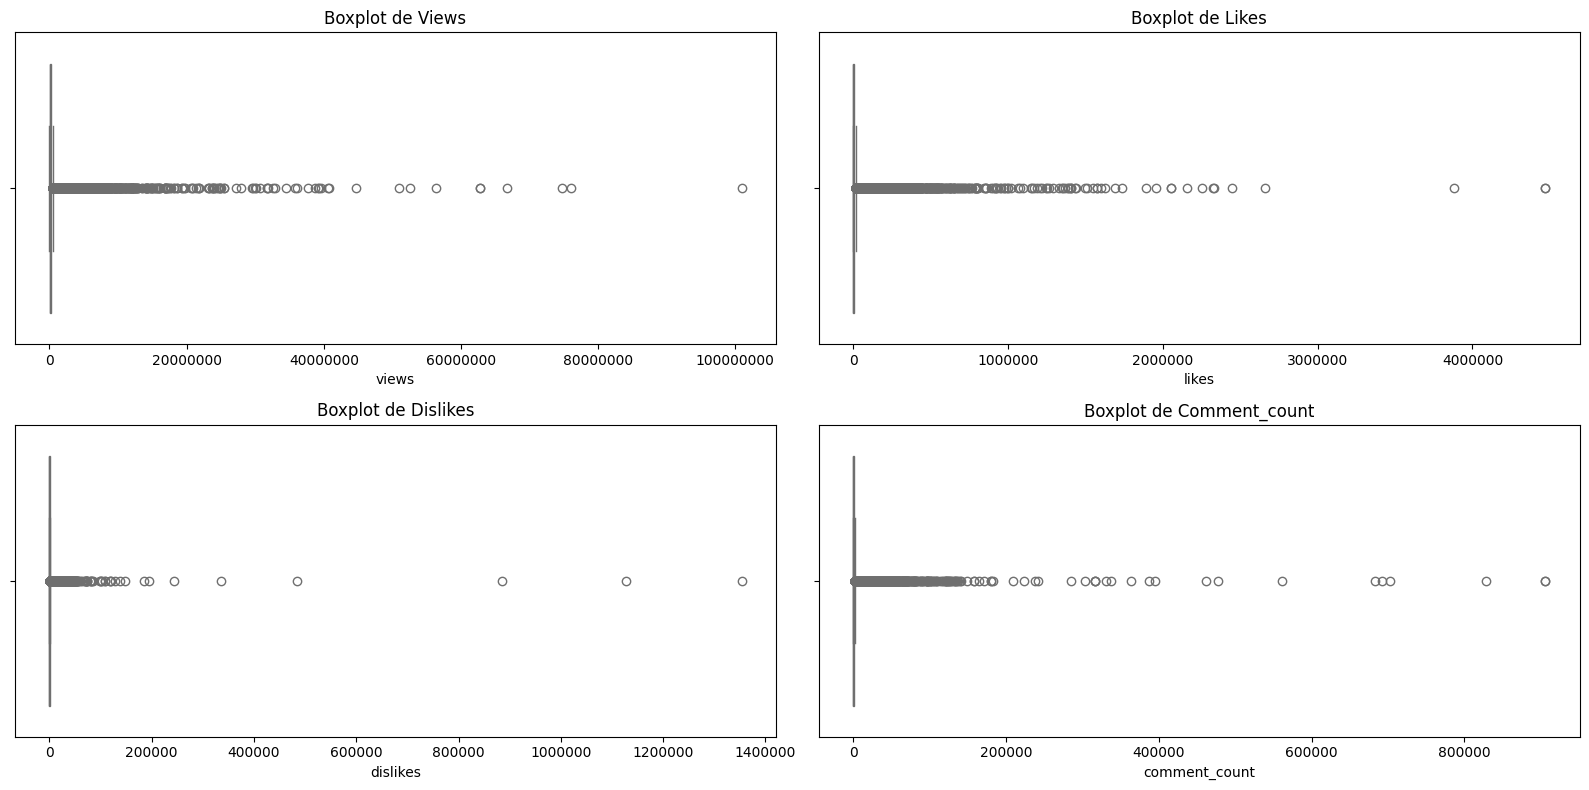

In [ ]:
# 3. VISUALIZACIÓN DE OUTLIERS (BOXPLOTS)
plt.figure(figsize=(16, 8))

# Variables clave a analizar
columnas_outliers = ['views', 'likes', 'dislikes', 'comment_count']

for i, col in enumerate(columnas_outliers, 1):
    plt.subplot(2, 2, i)
    # Usamos escala normal para ver los outliers reales
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot de {col.capitalize()}')

    # Formatear el eje X para que no muestre notación científica (ej. 1e7)
    plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

En este caso se observan Outliers gracias al boxplot, sin embargo por ahora para los requerimientos no serán tratados pues estos valores pueden representar a los videos megavirales que corresponden a la data real

In [ ]:
# 4. CREACIÓN DE NUEVAS VARIABLES (RATIOS)

# Ratio de Likes por cada 100 vistas (%)
df['ratio_likes'] = (df['likes'] / df['views']) * 100

# Ratio de Dislikes por cada 100 vistas (%)
df['ratio_dislikes'] = (df['dislikes'] / df['views']) * 100

# Ratio de Comentarios por cada 100 vistas (%)
df['ratio_comentarios'] = (df['comment_count'] / df['views']) * 100

# VERIFICACIÓN DE LAS NUEVAS VARIABLES
print("--- RESUMEN DE LOS NUEVOS RATIOS GENERADOS ---")
display(df[['title', 'views', 'ratio_likes', 'ratio_dislikes', 'ratio_comentarios']].head())

print("\n--- ESTADÍSTICAS DESCRIPTIVAS DE LOS RATIOS ---")
display(df[['ratio_likes', 'ratio_dislikes', 'ratio_comentarios']].describe())

--- RESUMEN DE LOS NUEVOS RATIOS GENERADOS ---


,title,views,ratio_likes,ratio_dislikes,ratio_comentarios
0,Capítulo 12 | MasterChef 2017,310130.0,1.348467,0.116403,0.592010
1,ALEXA EX-INTEGRANTE DEL GRUPO TIMBIRICHE RENUN...,104972.0,0.258164,0.165758,0.351522
2,LOUIS CKAGÓ - EL PULSO DE LA REPÚBLICA,136064.0,7.426652,0.195496,0.446114
3,Sismo de 6.7 sacude Costa Rica 12 Noviembre 2017,96153.0,0.393123,0.177842,0.216322
4,DOG HACKS | MUSAS LESSLIE LOS POLINESIOS,499965.0,11.557009,0.136210,1.485704



--- ESTADÍSTICAS DESCRIPTIVAS DE LOS RATIOS ---


,ratio_likes,ratio_dislikes,ratio_comentarios
count,40427.000000,40427.000000,40427.000000
mean,4.787704,0.175686,0.758610
std,5.060754,0.303212,1.352639
min,0.000000,0.000000,0.000000
25%,0.728226,0.065399,0.117677
50%,2.938122,0.113122,0.350430
75%,7.615150,0.191162,0.900940
max,42.737789,11.983891,38.433515


# Requerimientos

In [ ]:
# REPARACIÓN AVANZADA DE IDs CORRUPTOS (#NAME?) BASADA EN TEXTO UNICO

# 1. Crear una máscara para identificar los registros corruptos
mascara_name_error = df['video_id'] == '#NAME?'
print(f"Cantidad inicial de registros con #NAME?: {mascara_name_error.sum()}")

# 2. Generar un identificador consistente combinando 'title' y 'channel_title'
# Usamos .astype(str) para evitar cualquier problema y reemplazamos espacios/caracteres extraños
id_generado = 'FIXED_' + df['channel_title'].astype(str) + '_' + df['title'].astype(str)
# Opcional: Limpiamos caracteres que puedan romper cadenas
id_generado = id_generado.str.replace(r'[^a-zA-Z0-9_]', '', regex=True)

# 3. Asignar el ID generado SOLO a las filas que tienen el error #NAME?
df.loc[mascara_name_error, 'video_id'] = id_generado[mascara_name_error]

# 4. Verificar que el ID '#NAME?' haya desaparecido por completo
print(f"Cantidad residual de registros con #NAME?: {(df['video_id'] == '#NAME?').sum()}")

Cantidad inicial de registros con #NAME?: 516
Cantidad residual de registros con #NAME?: 0


In [ ]:
# Para algunas preguntas Q1-Q4 separamos valores en df_unicos, para evitar el sesgo
# Pues hay videos que ingresaron varias veces a tendencia
df_unicos = df.sort_values('views', ascending=False).drop_duplicates(subset=['video_id'], keep='first')

print(f"\nTamaño del dataset original limpio: {df.shape[0]}")
print(f"Tamaño del dataset de VIDEOS ÚNICOS (df_unicos): {df_unicos.shape[0]}")


Tamaño del dataset original limpio: 40427
Tamaño del dataset de VIDEOS ÚNICOS (df_unicos): 33936


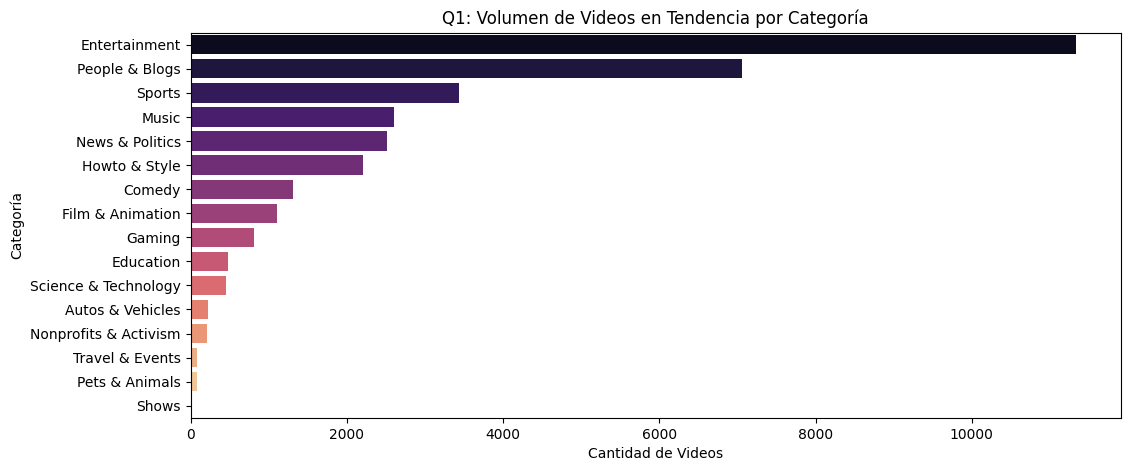

In [ ]:
# Q1. ¿Qué categorías son las de mayor tendencia?
plt.figure(figsize=(12, 5))
orden_cat = df_unicos['category_name'].value_counts().index
sns.countplot(y='category_name', data=df_unicos, order=orden_cat, palette='magma')
plt.title('Q1: Volumen de Videos en Tendencia por Categoría')
plt.xlabel('Cantidad de Videos')
plt.ylabel('Categoría')
plt.show()

In [ ]:
df_unicos['category_name'].value_counts()

,count
category_name,
Entertainment,11339
People & Blogs,7063
Sports,3440
Music,2597
News & Politics,2518
Howto & Style,2211
Comedy,1306
Film & Animation,1109
Gaming,813


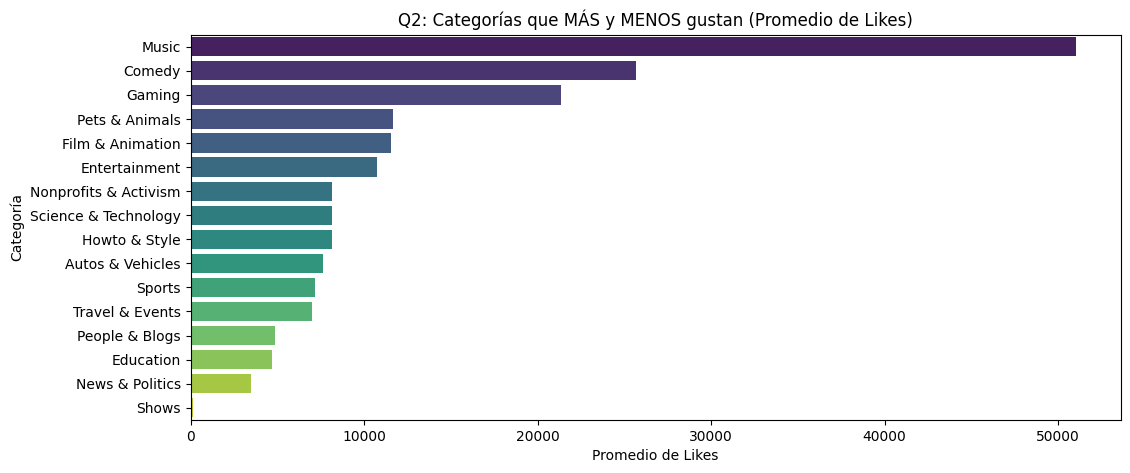

In [ ]:
# Q2. Categorías que más y menos gustan (Promedio de Likes)
plt.figure(figsize=(12, 5))
likes_por_cat = df_unicos.groupby('category_name')['likes'].mean().sort_values(ascending=False)
sns.barplot(x=likes_por_cat.values, y=likes_por_cat.index, palette='viridis')
plt.title('Q2: Categorías que MÁS y MENOS gustan (Promedio de Likes)')
plt.xlabel('Promedio de Likes')
plt.ylabel('Categoría')
plt.show()

In [ ]:
likes_por_cat

,likes
category_name,
Music,51051.259145
Comedy,25677.785605
Gaming,21317.670357
Pets & Animals,11655.294872
Film & Animation,11566.955816
Entertainment,10759.495987
Nonprofits & Activism,8167.995238
Science & Technology,8139.335526
Howto & Style,8119.724107


In [ ]:
# ==========================================
# Q3 & Q4. Proporciones (Ratios)
# Creamos las variables específicas solicitadas
# ==========================================
# Para Q3: Si dislikes es 0, lo cambiamos a NaN para no inflar el ratio de forma absurda
dislikes_limpios = df_unicos['dislikes'].replace(0, np.nan)
df_unicos['ratio_like_dislike'] = df_unicos['likes'] / dislikes_limpios

# Para Q4: Si comment_count es 0, lo cambiamos a NaN (ignora videos con comentarios desactivados)
comentarios_limpios = df_unicos['comment_count'].replace(0, np.nan)
df_unicos['ratio_views_comments'] = df_unicos['views'] / comentarios_limpios

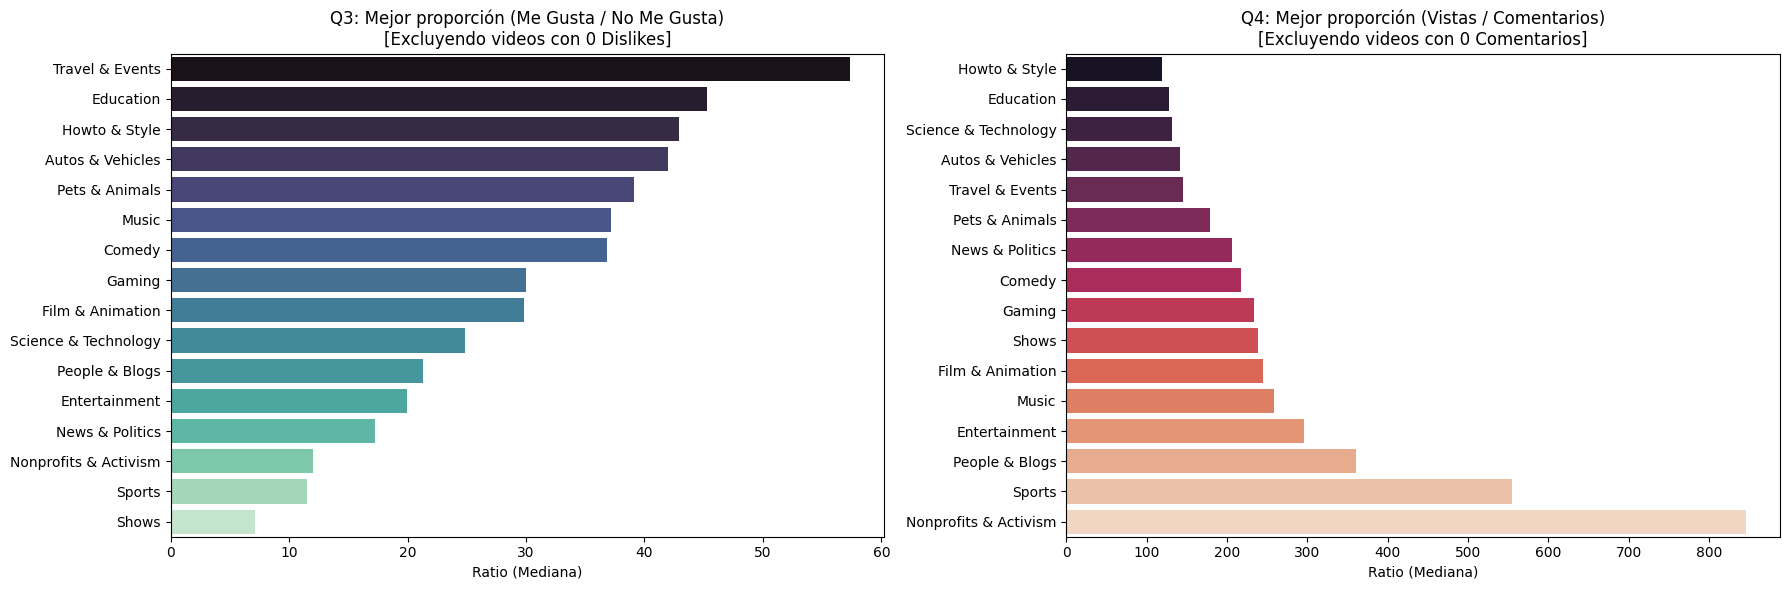

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Q3: Ratio Me gusta / No me gusta (Promedio por categoría)
# ¿Cuántos likes recibe un video por cada dislike? (Más alto mejor)
ratio_ld = df_unicos.groupby('category_name')['ratio_like_dislike'].median().sort_values(ascending=False)
sns.barplot(x=ratio_ld.values, y=ratio_ld.index, palette='mako', ax=axes[0])
axes[0].set_title('Q3: Mejor proporción (Me Gusta / No Me Gusta)\n[Excluyendo videos con 0 Dislikes]')
axes[0].set_xlabel('Ratio (Mediana)')
axes[0].set_ylabel('')

# Q4: Ratio Vistas / Comentarios (Promedio por categoría)
# ¿Cuántas vistas necesita un video para conseguir un comentario?" (Más bajo mejor)
ratio_vc = df_unicos.groupby('category_name')['ratio_views_comments'].median().sort_values()
sns.barplot(x=ratio_vc.values, y=ratio_vc.index, palette='rocket', ax=axes[1])
axes[1].set_title('Q4: Mejor proporción (Vistas / Comentarios)\n[Excluyendo videos con 0 Comentarios]')
axes[1].set_xlabel('Ratio (Mediana)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

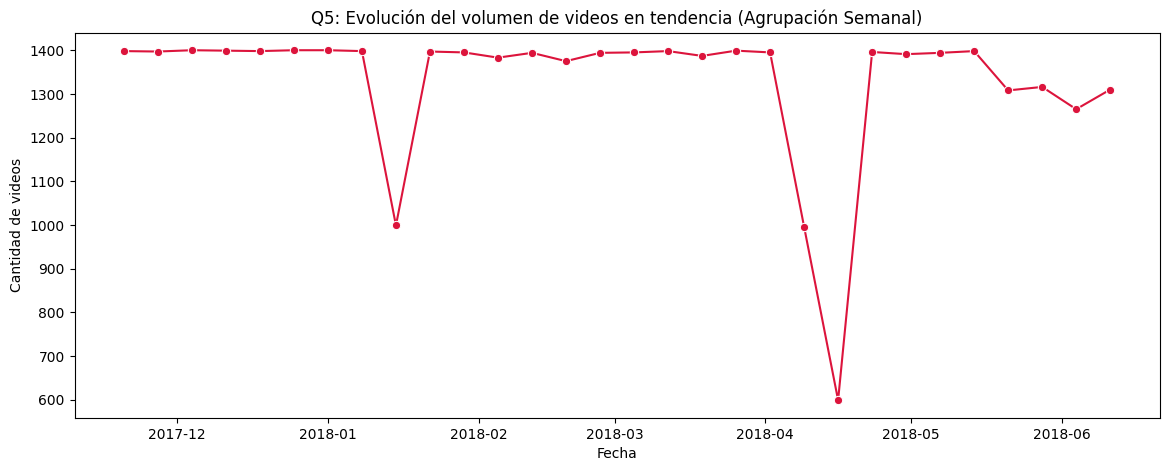

In [ ]:
# Q5. Volumen de videos a lo largo del tiempo (Semanal)
plt.figure(figsize=(14, 5))
# Agrupamos por semana para evitar sesgos de meses incompletos
df_tiempo = df.groupby(pd.Grouper(key='trending_date', freq='W-MON')).size().reset_index(name='cantidad')

# Quitamos la última semana pues esta incompleta por el rango de días de dataset
df_tiempo = df_tiempo.iloc[:-1]

sns.lineplot(data=df_tiempo, x='trending_date', y='cantidad', marker='o', color='crimson')
plt.title('Q5: Evolución del volumen de videos en tendencia (Agrupación Semanal)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de videos')
plt.show()

In [ ]:
df_tiempo

,trending_date,cantidad
0,2017-11-20,1398
1,2017-11-27,1397
2,2017-12-04,1400
3,2017-12-11,1399
4,2017-12-18,1398
5,2017-12-25,1400
6,2018-01-01,1400
7,2018-01-08,1398
8,2018-01-15,999
9,2018-01-22,1397


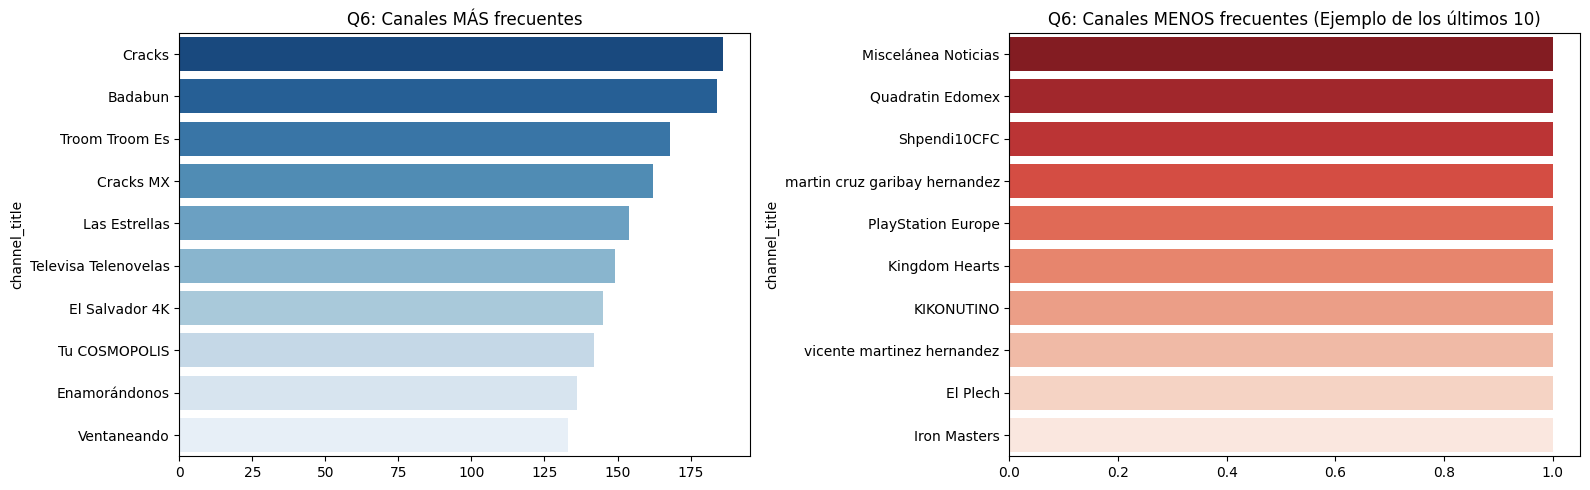

In [ ]:
# Q6. Canales con más y menos frecuencia
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_canales = df['channel_title'].value_counts().head(10)
low_canales = df['channel_title'].value_counts().tail(10) # Canales que solo aparecieron 1 vez

sns.barplot(x=top_canales.values, y=top_canales.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Q6: Canales MÁS frecuentes')

sns.barplot(x=low_canales.values, y=low_canales.index, palette='Reds_r', ax=axes[1])
axes[1].set_title('Q6: Canales MENOS frecuentes (Ejemplo de los últimos 10)')
plt.tight_layout()
plt.show()

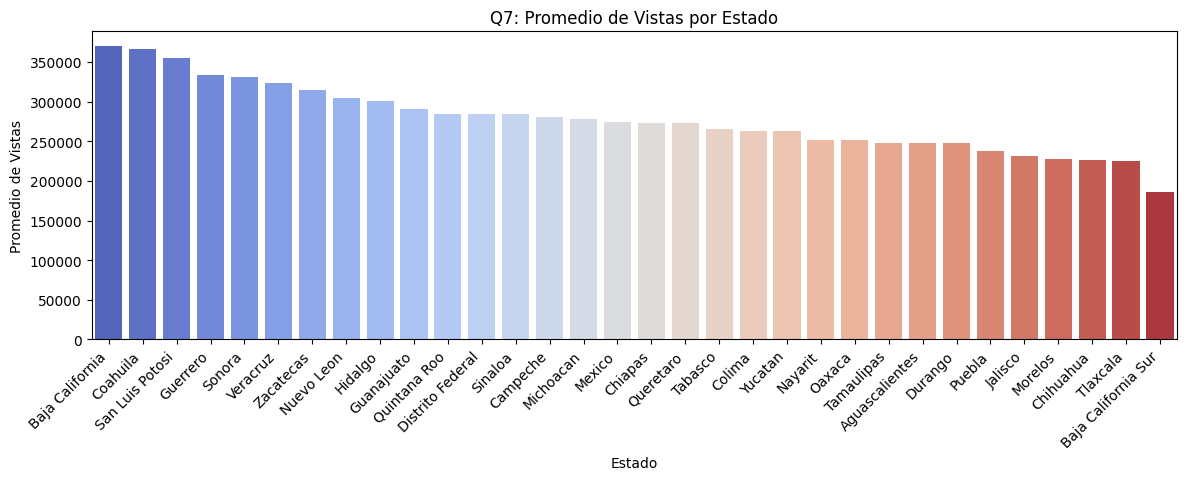

In [ ]:
# Q7. Análisis Geográfico

# Agrupamos los datos por estado usando el promedio (Evita sesgo de población)
df_estado = df_unicos.groupby('state')[['views', 'likes', 'dislikes']].mean().reset_index()

# Gráfico 1: Vistas Promedio por Estado
plt.figure(figsize=(14, 4))
df_estado_sorted_views = df_estado.sort_values('views', ascending=False)
sns.barplot(data=df_estado_sorted_views, x='state', y='views', palette='coolwarm')
plt.title('Q7: Promedio de Vistas por Estado')
plt.ylabel('Promedio de Vistas')
plt.xlabel('Estado')
plt.xticks(rotation=45, ha='right')
plt.show()

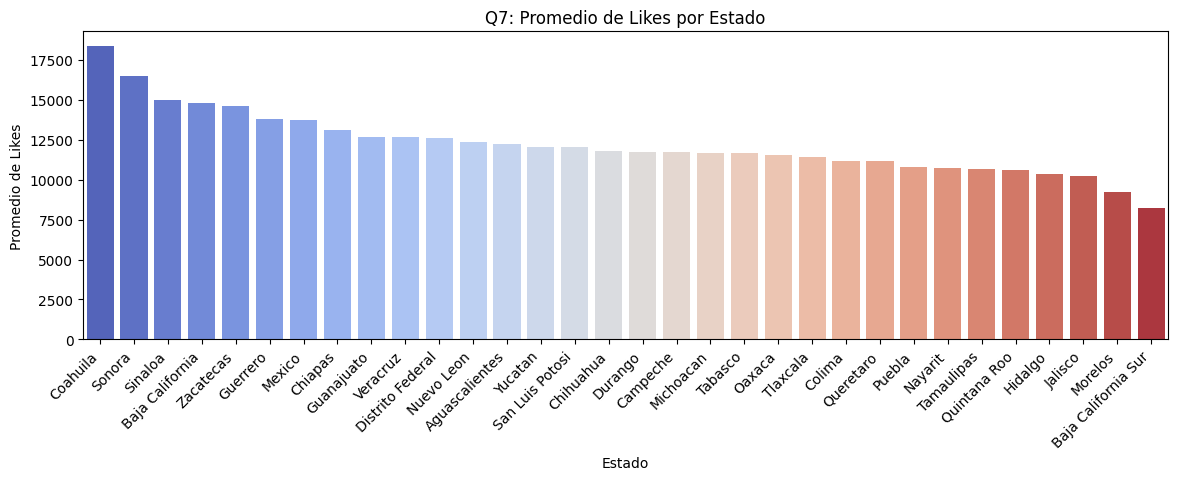

In [ ]:
# Gráfico 2: Likes Promedio por Estado
plt.figure(figsize=(14, 4))
df_estado_sorted_likes = df_estado.sort_values("likes", ascending=False)
sns.barplot(data=df_estado_sorted_likes, x="state", y="likes", palette="coolwarm")
plt.title("Q7: Promedio de Likes por Estado")
plt.ylabel("Promedio de Likes")
plt.xlabel("Estado")
plt.xticks(rotation=45, ha="right")
plt.show()

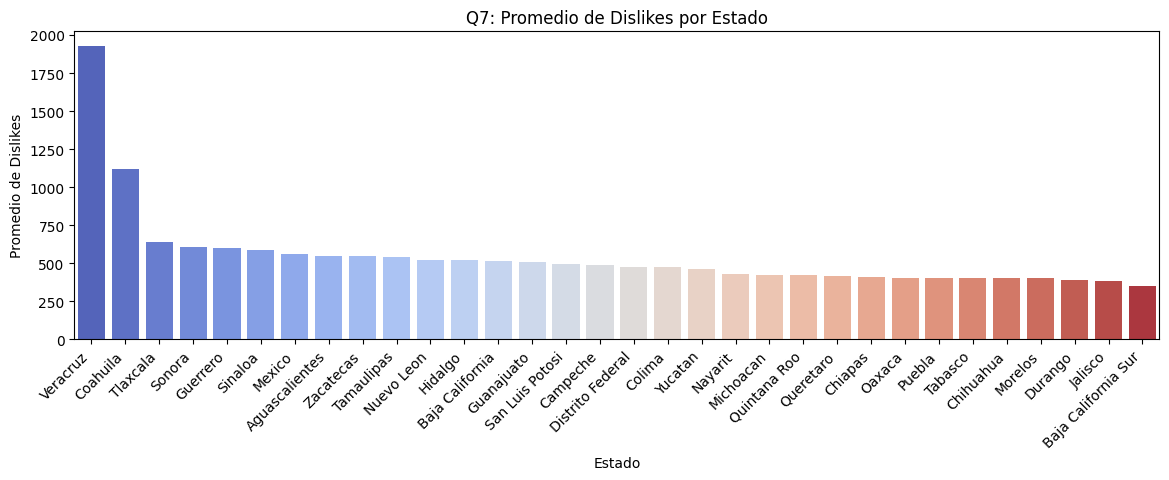

In [ ]:
# Gráfico 3: Dislikes Promedio por Estado
plt.figure(figsize=(14, 4))
df_estado_sorted_dislikes = df_estado.sort_values("dislikes", ascending=False)
sns.barplot(data=df_estado_sorted_dislikes, x="state", y="dislikes", palette="coolwarm")
plt.title("Q7: Promedio de Dislikes por Estado")
plt.ylabel("Promedio de Dislikes")
plt.xlabel("Estado")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
df_unicos.loc[
    df_unicos['state'] == 'Mexico',
    ['title', 'dislikes', 'state']
].sort_values('dislikes', ascending=False)

,title,dislikes,state
31773,Lil Pump - ESSKEETIT (Official Music Video),71315.0,Mexico
32641,OFICIAL: Se suspende Copa Mundial Rusia 2018 [...,50392.0,Mexico
12251,Descansa En Paz Yuawi López El niño de Movimie...,31093.0,Mexico
13145,Dua Lipa - IDGAF (Official Music Video),22034.0,Mexico
16860,Red Velvet 레드벨벳 'Bad Boy' MV,21766.0,Mexico
...,...,...,...
10839,Año nuevo en México 2018 - Jorge Amarilla,0.0,Mexico
37554,Hijas de la Luna Capitulo 61 AVANCE LUNES 14 d...,0.0,Mexico
23202,"Masada y Daga vs Violento Jack y Aeroboy, The ...",0.0,Mexico
10801,Me Declaro Culpable Avance 2 de Enero,0.0,Mexico


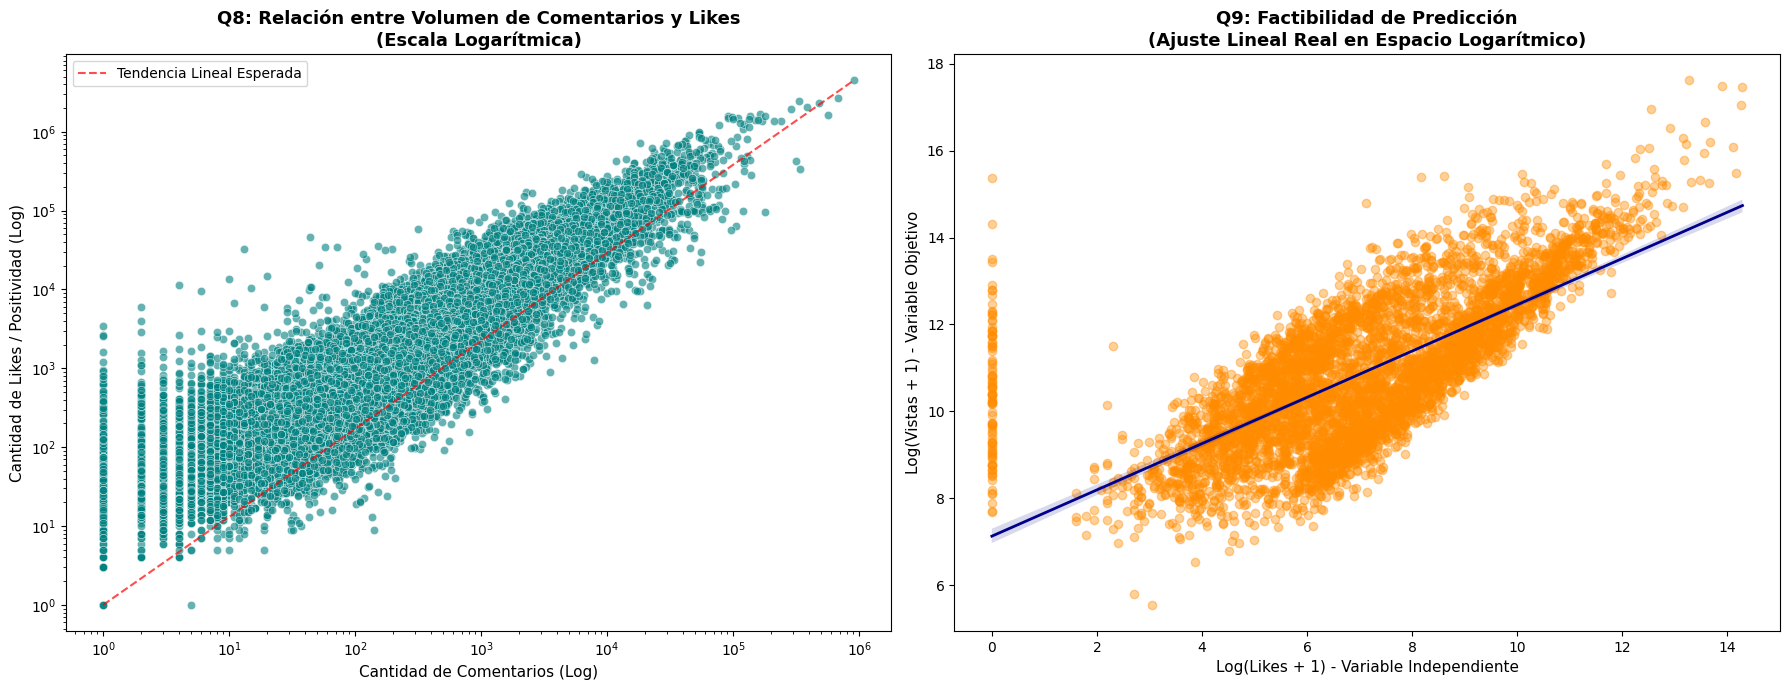

In [ ]:
# Q8: Los videos en tendencia son los que mayor cantidad de comentarios positivos

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Relación entre Likes (Simular la Positividad) y Cantidad de Comentarios

sns.scatterplot(
    data=df_unicos,
    x='comment_count',
    y='likes',
    alpha=0.6,
    color='teal',
    ax=axes[0]
)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Q8: Relación entre Volumen de Comentarios y Likes\n(Escala Logarítmica)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de Comentarios (Log)', fontsize=11)
axes[0].set_ylabel('Cantidad de Likes / Positividad (Log)', fontsize=11)

# Línea diagonal de referencia
axes[0].plot([df_unicos['comment_count'].min()+1, df_unicos['comment_count'].max()],
             [df_unicos['likes'].min()+1, df_unicos['likes'].max()],
             color='red', linestyle='--', alpha=0.7, label='Tendencia Lineal Esperada')
axes[0].legend()


# =========================================================================

# Q9: Factibilidad de Predicción (Línea de Regresión Vistas vs Likes)

# Extraemos la muestra para optimizar rendimiento en Colab
df_sample = df_unicos.sample(n=min(5000, len(df_unicos)), random_state=42).copy()

# Aplicamos la transformación logarítmica real en el DataFrame para que regplot calcule bien el ajuste
df_sample['log_likes'] = np.log1p(df_sample['likes'])
df_sample['log_views'] = np.log1p(df_sample['views'])

# Graficamos la regresión directamente sobre los datos transformados
sns.regplot(
    data=df_sample,
    x='log_likes',
    y='log_views',
    scatter_kws={'alpha':0.4, 'color': 'darkorange'},
    line_kws={'color': 'darkblue', 'linewidth': 2},
    ax=axes[1]
)
axes[1].set_title('Q9: Factibilidad de Predicción\n(Ajuste Lineal Real en Espacio Logarítmico)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Likes + 1) - Variable Independiente', fontsize=11)
axes[1].set_ylabel('Log(Vistas + 1) - Variable Objetivo', fontsize=11)

plt.tight_layout()
plt.show()

**Interpretación del Gráfico 8:** Hay una nube de puntos densa que sube de forma diagonal y compacta. Esto demuestra que sí, a mayor volumen de comentarios en los videos en tendencia, hay un incremento masivo y directamente proporcional en la cantidad de "Likes". La hipótesis de que los videos en tendencia mantienen gran cantidad de comentarios positivos se sostiene.

**Interpretación del Gráfico 9:** Se observa una relación positiva entre la cantidad de likes y el número de vistas. En escala logarítmica, la nube de puntos presenta una tendencia ascendente, lo que indica que los videos con mayor cantidad de likes tienden también a registrar un mayor número de visualizaciones. Sin embargo, la dispersión de los datos evidencia que los likes no explican por sí solos el comportamiento de las vistas, por lo que sería recomendable incorporar variables adicionales para mejorar la capacidad predictiva de un modelo de regresión. Aquello se realizará en la fase a continuación.

# Modelo Predictivo

Técnica elegida: Regresión Lineal Múltiple

Variable objetivo: Vistas

In [ ]:
# Creación de nuevas variables
# Longitud del título del video
df_unicos['title_length'] = df_unicos['title'].astype(str).apply(len)

# Cantidad de etiquetas (tags) - Separadas por la barra vertical '|'
# Si dice "none", el conteo es 0
df_unicos['num_tags'] = df_unicos['tags'].astype(str).apply(lambda x: 0 if x.lower() == 'none' else len(x.split('|')))

# Variable de ranking por categoría
# CALCULAR EL PROMEDIO DE VISTAS POR CATEGORÍA
# Usamos df_unicos para evitar el sesgo de videos repetidos
vistas_por_cat = df_unicos.groupby('category_name')['views'].mean().sort_values(ascending=False)

print("--- Vistas Promedio por Categoría ---")
print(vistas_por_cat)

# DEFINIR LOS UMBRALES (RANGOS)
# Dividimos las categorías en 3 grupos usando los cuantiles (33% y 66%)
q33 = vistas_por_cat.quantile(0.33)
q66 = vistas_por_cat.quantile(0.66)

def asignar_rango_popularidad(categoria):
    # Buscamos el promedio de vistas de esta categoría
    if categoria not in vistas_por_cat:
        return 1 # Por si hay alguna categoría sin datos

    promedio_vistas = vistas_por_cat[categoria]

    if promedio_vistas >= q66:
        return 3  # Popularidad Alta
    elif promedio_vistas >= q33:
        return 2  # Popularidad Media
    else:
        return 1  # Popularidad Baja

# Creamos la nueva variable numérica en nuestro dataset
df_unicos['category_popularity_rank'] = df_unicos['category_name'].apply(asignar_rango_popularidad)

--- Vistas Promedio por Categoría ---
category_name
Music                    945792.474008
Pets & Animals           463844.512821
Comedy                   409984.640888
Gaming                   369220.439114
Sports                   322633.088953
Film & Animation         313839.597836
Science & Technology     293372.745614
Entertainment            245535.063762
Nonprofits & Activism    180771.966667
Howto & Style            166140.996834
News & Politics          137537.866561
Autos & Vehicles         137217.830357
Travel & Events          137002.517241
People & Blogs           126806.759451
Education                 78518.771784
Shows                     21812.000000
Name: views, dtype: float64


In [ ]:
# 2. SELECCIÓN DE VARIABLES NUMÉRICAS Y TRANSFORMACIÓN LOGARÍTMICA
# Variables numéricas clave para el análisis
variables_clave = ['views', 'likes', 'dislikes', 'comment_count', 'title_length', 'num_tags', 'category_popularity_rank']
df_original = df_unicos[variables_clave].dropna()
df_original = df_original[df_original['likes'] > 0]

# Creamos un segundo dataframe aplicando log1p (logaritmo de x + 1) a las métricas de negocio
df_log = pd.DataFrame()
df_log['log_views'] = np.log1p(df_original['views'])
df_log['log_likes'] = np.log1p(df_original['likes'])
df_log['log_dislikes'] = np.log1p(df_original['dislikes'])
df_log['log_comment_count'] = np.log1p(df_original['comment_count'])
df_log['title_length'] = df_original['title_length'] # No requiere logaritmo por su escala pequeña
df_log['num_tags'] = df_original['num_tags']         # No requiere logaritmo por su escala pequeña
df_log['category_popularity_rank'] = df_original['category_popularity_rank']         # No requiere logaritmo por su escala pequeña


**¿Por qué usamos transformaciones logarítmicas?**

Para mejorar la correlación, además una Regresión Lineal funciona mejor cuando existe una relación aproximadamente lineal entre las variables.

* Escala original: la relación suele ser curvada, con mucha dispersión y valores extremos.
* Escala logarítmica: la relación se vuelve más cercana a una línea recta, disminuye el efecto de los valores extremadamente grandes y los supuestos de la regresión suelen cumplirse mejor.

En el caso de YouTube, variables como views, likes, dislikes y comment_count tienen distribuciones muy sesgadas (unos pocos videos concentran millones de interacciones). Por eso es una práctica común es construir el modelo usando log1p(views), log1p(likes), log1p(dislikes) y log1p(comment_count) en lugar de los valores originales. Esto suele producir un modelo más estable y con mejor capacidad predictiva.

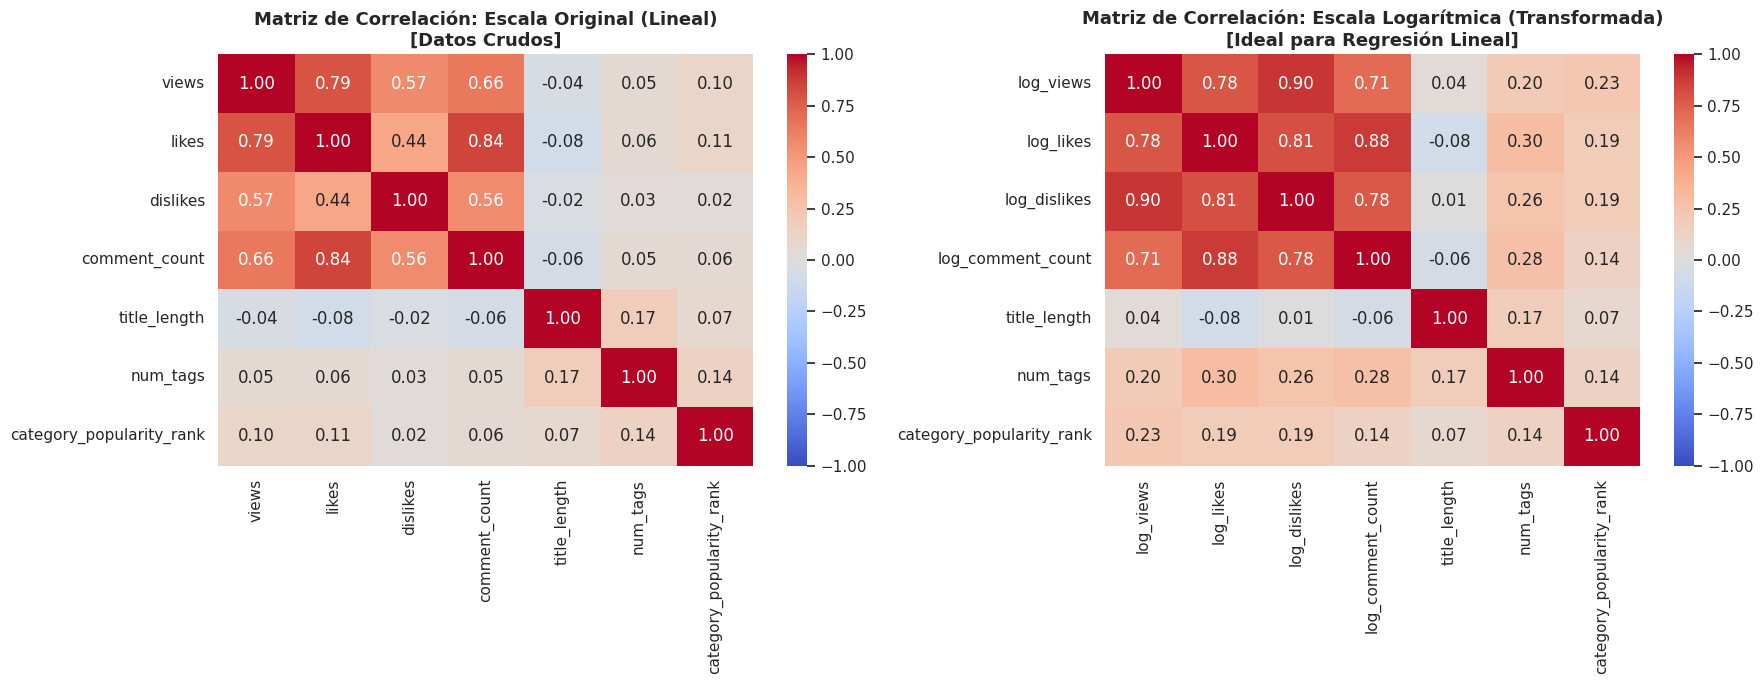

In [ ]:
# 3. VISUALIZACIÓN DE MATRICES DE CORRELACIÓN
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz 1: Escala Original
corr_original = df_original.corr()
sns.heatmap(corr_original, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Matriz de Correlación: Escala Original (Lineal)\n[Datos Crudos]', fontsize=13, fontweight='bold')

# Matriz 2: Escala Logarítmica
corr_log = df_log.corr()
sns.heatmap(corr_log, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Matriz de Correlación: Escala Logarítmica (Transformada)\n[Ideal para Regresión Lineal]', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**Elección de variables para el modelo:**

Basándonos en los números de la matriz de correlación, esta es la selección de variables independientes (X):

1.	log_likes (Predictor principal) **¿Por qué?** Muestra una alta correlación con las vistas (0.78), así como en la de datos crudos (0.79).

2. category_popularity_rank (El Contexto) **¿Por qué?** Tiene una correlación positiva y útil con las vistas (0.23), pero lo más importante es que su correlación con log_likes es baja (0.19). Aporta información fresca al modelo sin causar multicolinealidad.

3.	num_tags (El Esfuerzo del creador) **¿Por qué?** Tiene una correlación de 0.20 con las vistas. Nos ayuda a medir si el esfuerzo del creador por posicionar el video mediante etiquetas afecta al resultado. De nuevo, su correlación con las otras variables elegidas es baja/manejable.

4. title_length (La Variable de Control) **¿Por qué?** Aunque su correlación con las vistas es casi nula (0.04), tiene una correlación de -0.08 con los likes y 0.07 con el ranking. En modelos de regresión múltiple, estas variables sirven para capturar pequeñas varianzas residuales (ruido) sin afectar a los predictores principales. Nos ayuda a responder a la pregunta: *"Si todo lo demás es igual, ¿importa el tamaño del título?"*.

In [ ]:
# 1. PREPARACIÓN DE MATRICES (X, y)

# Definimos nuestras variables independientes (Predictoras)
features = ['log_likes', 'category_popularity_rank', 'num_tags', 'title_length']
X = df_log[features]

# Definimos nuestra variable dependiente (Objetivo)
y = df_log['log_views']

In [ ]:
# 2. DIVISIÓN EN ENTRENAMIENTO Y PRUEBA (Train / Test Split)
# Usamos un 80% para entrenar y 20% para validar el modelo.
# random_state=42 asegura que el split sea reproducible (siempre dé los mismos números al correrlo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Registros para Entrenamiento: {X_train.shape[0]}")
print(f"Registros para Prueba: {X_test.shape[0]}")

Registros para Entrenamiento: 26701
Registros para Prueba: 6676


In [ ]:
# 3. ENTRENAMIENTO DEL MODELO DE REGRESIÓN LINEAL
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Realizamos las predicciones sobre el conjunto de prueba
y_pred_log = modelo.predict(X_test)

In [ ]:
# 4. CÁLCULO DE MÉTRICAS (Escala Logarítmica)
r2 = r2_score(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)
mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)

print("\n==================================================")
print("   MÉTRICAS DE EVALUACIÓN (Escala Logarítmica)   ")
print("==================================================")
print(f"R-cuadrado (R²): {r2:.4f} ({r2*100:.2f}% de la varianza explicada)")
print(f"MAE (Log):       {mae_log:.4f}")
print(f"MSE (Log):       {mse_log:.4f}")
print(f"RMSE (Log):      {rmse_log:.4f}")


   MÉTRICAS DE EVALUACIÓN (Escala Logarítmica)   
R-cuadrado (R²): 0.6223 (62.23% de la varianza explicada)
MAE (Log):       0.8496
MSE (Log):       1.0805
RMSE (Log):      1.0395


In [ ]:
# 5. CÁLCULO DE MÉTRICAS (Escala Real - Vistas Originales)

# Transformamos las predicciones y los valores reales de vuelta usando expm1
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print("\n==================================================")
print("     MÉTRICAS EN UNIDADES REALES (Vistas)       ")
print("==================================================")
print(f"MAE Real:  {mae_real:,.2f} vistas de error promedio")
print(f"RMSE Real: {rmse_real:,.2f} vistas (Penalizando desvíos grandes)")


     MÉTRICAS EN UNIDADES REALES (Vistas)       
MAE Real:  169,470.00 vistas de error promedio
RMSE Real: 967,664.41 vistas (Penalizando desvíos grandes)


**1. Interpretación del Rendimiento ($R^2$ y Errores)**

**R-cuadrado ($R^2 = 62.23\%$):** Esto significa que las 4 variables predictoras seleccionadas logran explicar casi las dos terceras partes (el 62.23%) de la variabilidad del éxito en visualizaciones de un video. Para un entorno tan dinámico y complejo como el comportamiento de usuarios en redes sociales, un $R^2$ superior al 60% en una Regresión Lineal Múltiple es un resultado sumamente robusto y de valor predictivo. El 37.77% restante de la varianza queda asociado a factores externos fuera del alcance de estas métricas, como el impacto visual de las miniaturas (thumbnails), la retención específica de la audiencia, la viralidad en otras plataformas o las recomendaciones directas del algoritmo de YouTube.

**La Brecha MAE vs. RMSE (El gran hallazgo):**

El MAE Real es de 169,470 vistas. Esto indica que, en promedio, las predicciones del modelo se desvían por aproximadamente 169 mil visualizaciones respecto al valor real.

El RMSE Real se situó en 967,664 vistas.

¿Qué significa estadísticamente esta diferencia? Confirma la sospecha inicial: el modelo es bastante preciso para la gran mayoría de los videos comunes, pero falla críticamente al intentar predecir los videos "Mega-Virales" (los valores atípicos extremos). Cuyas explosiones de tráfico exponencial desafían la linealidad del modelo, elevando el RMSE debido a la penalización cuadrática de los desvíos grandes.

In [ ]:
# 6. REVISIÓN DE COEFICIENTES (Ecuación del Modelo)
print("\n==================================================")
print("          COEFICIENTES DEL MODELO                 ")
print("==================================================")
print(f"Intercepto (Beta 0): {modelo.intercept_:.4f}" if hasattr(modelo, 'intercept_') else "Intercepto: N/A")
for col, coef in zip(features, modelo.coef_):
    print(f"Coeficiente para {col}: {coef:.4f}")


          COEFICIENTES DEL MODELO                 
Intercepto (Beta 0): 5.4643
Coeficiente para log_likes: 0.6463
Coeficiente para category_popularity_rank: 0.2040
Coeficiente para num_tags: -0.0088
Coeficiente para title_length: 0.0086


La ecuación matemática del modelo en escala logarítmica:

$$\log(\text{views} + 1) = 5.4643 + 0.6463 \cdot \log(\text{likes} + 1) + 0.2040 \cdot \text{category_popularity_rank} - 0.0088 \cdot \text{num_tags} + 0.0086 \cdot \text{title_length}$$

Al analizar el peso ($\beta$) de cada variable, se pueden extraer conclusiones de negocio muy relevantes:

* log_likes ($\beta = 0.6463$): Es, por mucho, el predictor más fuerte y
dominante. Al ser una relación log-log, se interpreta como elasticidad: por cada 10% de incremento en los Likes de un video, se espera un incremento aproximado del 5.4% en las Vistas. La aprobación de la comunidad es el motor principal.

* category_popularity_rank ($\beta = 0.2040$): Tiene un impacto positivo saludable. Esto demuestra que pertenecer a una categoría que históricamente es popular en tendencias le otorga al video un "impulso base" inmediato en visualizaciones.

* num_tags ($\beta = -0.0088$): Este coeficiente es prácticamente cero y ligeramente negativo. Conclusión de negocio: Rellenar un video con decenas de etiquetas (tags) no ayuda a ganar más vistas en el entorno actual de YouTube. De hecho, el signo negativo suele reflejar que los videos con menos tracción orgánica son los que los creadores intentan "salvar" sobrecargándolos de etiquetas de forma desesperada.

* title_length ($\beta = 0.0086$): Es prácticamente cero. La longitud del título no influye de manera significativa en si un video tendrá más o menos vistas una vez que entra en tendencias.

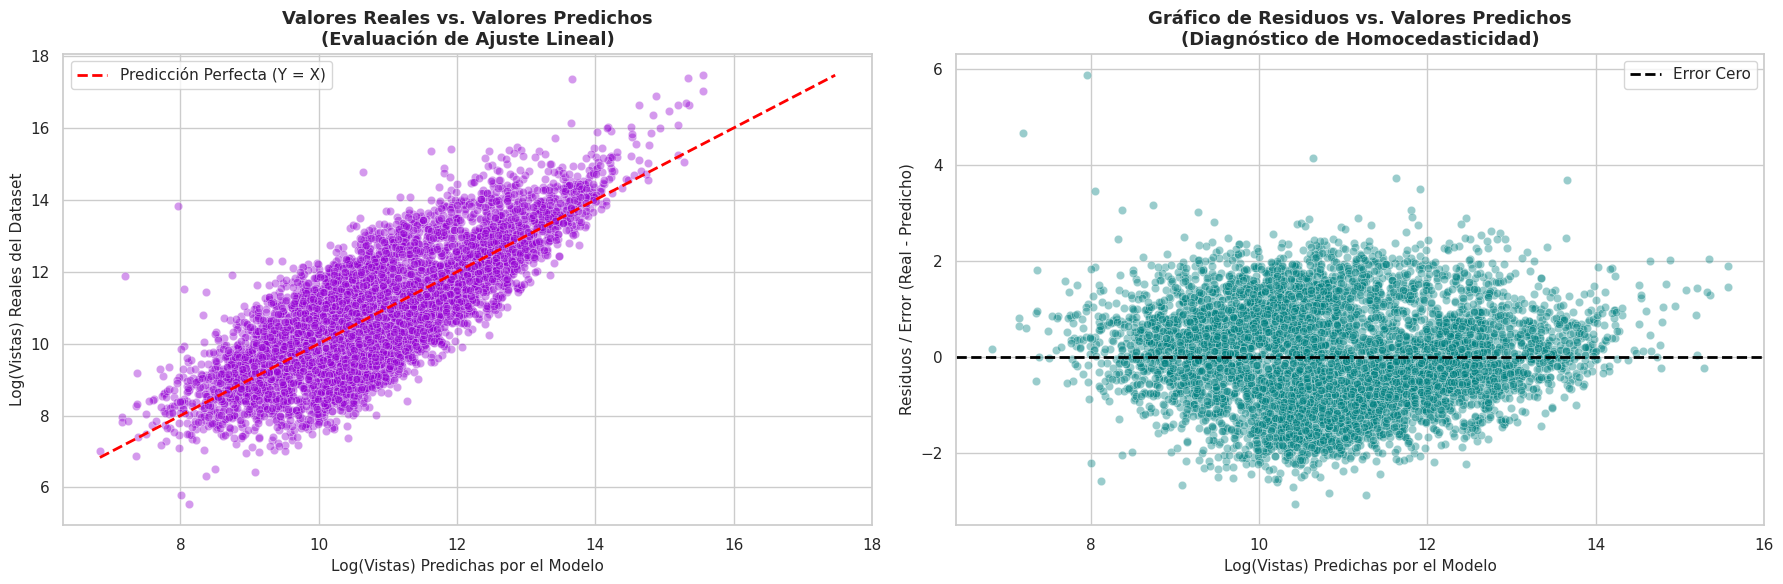

In [ ]:
# Calcular los residuos matemáticos (en escala logarítmica)
residuos_log = y_test - y_pred_log

# Configurar el lienzo de visualización
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set_theme(style="whitegrid")

# Gráfico 1: Valores Reales vs. Valores Predichos (Escala Logarítmica)
sns.scatterplot(x=y_pred_log, y=y_test, alpha=0.4, color='darkviolet', ax=axes[0])

# Encontrar los límites para trazar una línea de identidad perfecta (y = x)
lims = [
    max(y_test.min(), y_pred_log.min()),  # Mínimo común
    max(y_test.max(), y_pred_log.max())   # Máximo común
]
axes[0].plot(lims, lims, color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (Y = X)')

axes[0].set_title('Valores Reales vs. Valores Predichos\n(Evaluación de Ajuste Lineal)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Log(Vistas) Predichas por el Modelo', fontsize=11)
axes[0].set_ylabel('Log(Vistas) Reales del Dataset', fontsize=11)
axes[0].legend()

# -------------------------------------------------------------------------

# Gráfico 2: Gráfico de Residuos vs. Valores Predichos
sns.scatterplot(x=y_pred_log, y=residuos_log, alpha=0.4, color='teal', ax=axes[1])

# Línea horizontal en cero (indica error cero)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2, label='Error Cero')

axes[1].set_title('Gráfico de Residuos vs. Valores Predichos\n(Diagnóstico de Homocedasticidad)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Vistas) Predichas por el Modelo', fontsize=11)
axes[1].set_ylabel('Residuos / Error (Real - Predicho)', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

**Conclusiones del Modelo de Regresión Lineal Múltiple**

1. **Diagnóstico Visual y Cumplimiento de Supuestos (Análisis de Gráficos)**

    El análisis visual de los gráficos de diagnóstico confirma que el modelo cumple satisfactoriamente con los supuestos estadísticos clave de la Regresión Lineal:

* **Ajuste Lineal Continuo (Gráfico 1):** Al observar la relación entre los Valores Reales vs. Predichos, se aprecia una única nube de puntos densa y homogénea que abraza de manera estrecha y ascendente la línea diagonal de predicción perfecta ($Y=X$). Esto demuestra que la transformación logarítmica aplicada a las variables de interacción fue una decisión metodológica correcta, logrando estabilizar una distribución que originalmente era exponencial para permitir que el algoritmo lineal opere con alta efectividad en todo el espectro de datos.

* **Homocedasticidad y Estabilidad del Error (Gráfico 2):** El gráfico de residuos evidencia un comportamiento saludable. Los errores de predicción se distribuyen de forma simétrica y aleatoria por encima y por debajo de la línea horizontal de error cero, sin exhibir patrones geométricos marcados o distorsiones estructurales (como formas de embudo o dispersiones anómalas). Esto valida el supuesto de homocedasticidad, garantizando que el modelo mantiene un nivel de varianza y predictibilidad constante a lo largo de los diferentes volúmenes de vistas estimados.

2. **Capacidad Explicativa y Precisión General ($R^2$ y MAE)**

    El modelo entrenado logra explicar el 62.23% de la varianza total del éxito de un video, lo cual representa un coeficiente de determinación ($R^2$) sumamente robusto para el análisis de plataformas digitales y comportamiento de audiencias. Respaldado por un MAE Real de 169,470 vistas, podemos concluir que el algoritmo funciona como una herramienta de negocio confiable y precisa para estimar el rendimiento de los videos que experimentan un ciclo de vida orgánico estándar dentro de la sección de Tendencias en YouTube México.

3. **El Fenómeno de la Viralidad Extrema (El Límite del Modelo Lineal)**

    A pesar del buen ajuste geométrico de los datos, los resultados también permiten identificar con claridad los límites de la linealidad frente a la naturaleza misma de internet. Al observar el extremo superior derecho del primer gráfico, se aprecia que los puntos que representan las visualizaciones más altas tienden a dispersarse y ubicarse ligeramente por encima de la línea roja de predicción. Asimismo, el RMSE Real (~967,000 vistas) se posiciona notablemente por encima del MAE.

    Esta discrepancia matemática indica que el modelo tiende a subestimar el alcance real de los videos "Mega-Virales". Al elevar los errores al cuadrado, el RMSE captura y penaliza con severidad estos desvíos extraordinarios, concluyendo que el crecimiento explosivo e impredecible de un gran fenómeno de masas responde a factores intangibles (como la tasa de retención de la audiencia, el impacto cultural del momento o el empuje del algoritmo de recomendación externa) que escapan a la capacidad de una ecuación lineal tradicional.